# **Income, Capital, and Time:**

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [39]:
data= pd.read_csv('data.csv')
data.shape

(42468, 14)

In [40]:
data.head(3)

,age,workclass,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,salary
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K


In [41]:
data.columns[0:-1]

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country'],
      dtype='object')

### **1. Distribution of Capital Gain:**

In [42]:
data["capital-gain"].unique()

array([    0,  7688,  3103,  6418,  7298,  3908, 14084,  5178, 15024,
       99999,  2597,  2907,  4650,  6497,  1055,  5013, 27828,  4934,
        4064,  3674,  2174, 10605,  3418,   114,  2580,  3411,  4508,
        4386,  8614, 13550,  6849,  2463,  3137,  2885,  2964,  1471,
       10566,  2354,  1424,  1455,  3325,  4416, 25236,   594,  2105,
        4787,  2829,   401,  4865,  1264,  1506, 10520,  3464,  2653,
       20051,  4101,  1797,  2407,  3471,  1086,  1848, 14344,  1151,
        2993,  2290, 15020,  9386,  2202,  3818,  2176,  5455, 11678,
        7978,  7262,  6514, 41310,  3456,  7430,  2414,  2062, 34095,
        1831,  6723,  5060, 15831,  2977,  2346,  3273,  2329,  9562,
        2635,  4931,  1731,  6097,   914,  7896,  5556,  1409,  3781,
        3942,  2538,  3887, 25124,  7443,  5721,  1173,  4687,  6612,
        6767,  2961,   991,  2036,  2936,  2050,  1111,  2228, 22040,
        3432,  6360,  2009,  1639, 18481,  2387])

In [43]:
dass= data["capital-gain"].value_counts(normalize=True).reset_index().sort_values(by= "proportion", ascending= False).head(10)
dass

,capital-gain,proportion
0,0,0.905882
1,15024,0.011797
2,7688,0.009419
3,7298,0.008430
4,99999,0.005675
5,3103,0.003579
6,5178,0.003391
7,5013,0.002731
8,4386,0.002520
9,8614,0.001931


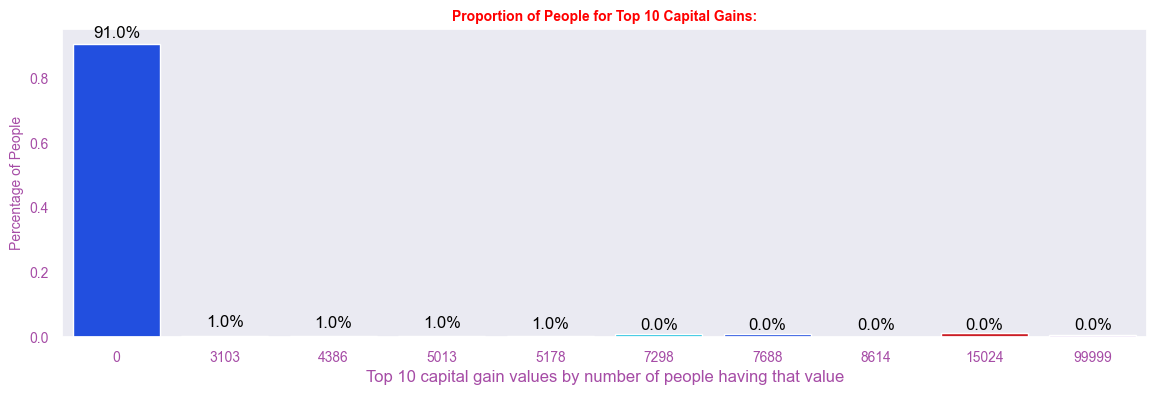

In [44]:
plt.figure(figsize=(14, 4))
sns.set_theme(context= "notebook", style= "dark", palette= "bright6", font_scale= 1.2)
sns.barplot(x= "capital-gain", y= "proportion", data= dass, palette= "bright6")
plt.title("Proportion of People for Top 10 Capital Gains:", fontsize= 10, fontweight= "bold", color= "Red")
plt.xlabel("Top 10 capital gain values by number of people having that value", color= "purple", fontsize= 12, alpha= 0.7)
plt.xticks(fontsize= 10, color= "purple", alpha= 0.7)
plt.ylabel("Percentage of People", color= "purple", fontsize= 10, alpha= 0.7)
plt.yticks(fontsize= 10, color= "purple", alpha= 0.7)
# annotation
for i, v in enumerate(dass["proportion"]):
    plt.text(i, v + 0.01, str(f'{round(v, 2)*100}%'), ha= "center", va= "bottom", fontsize= 12, color= "black")
plt.show()

The plot shows that more then 90% people (~91%) do not have income in the form of capital gains as indicated by 0 capital gain value. Nearly 1% people have capital gain of 3103, other 1% have capital-gain of 4386, other 1% have capital gain of 5013 and other 1% have 5178 as their capital gain income. Other values accounts for far less then one percent people for each indicating very few people have very high capital-gains. Also, As the the value of capital gain increases (from left to right in the plot), the proportion of people having that gain also decreases. And, more than 90% people from the dataset have no capital-gain.

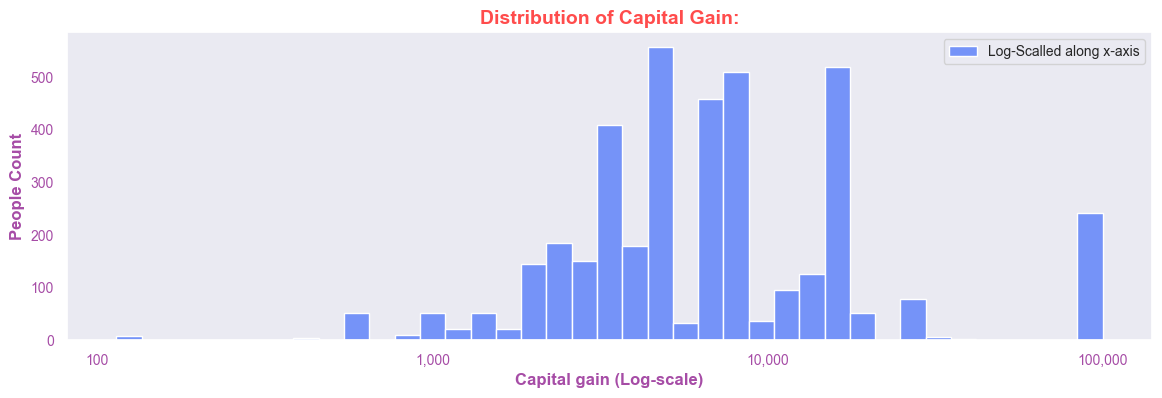

In [45]:
plt.figure(figsize=(14, 4))
sns.histplot(data["capital-gain"], kde=True, log_scale=True, legend= True)
plt.gca().set_xticklabels([f"{int(x):,}" for x in plt.gca().get_xticks().tolist()])
plt.legend(labels= ["Log-Scalled along x-axis"], fontsize= 10, loc= "upper right")
plt.title("Distribution of Capital Gain:", fontsize= 14, fontweight= "bold", color= "Red", alpha= 0.7)
plt.xlabel("Capital gain (Log-scale)", fontsize= 12, color= "purple", alpha= 0.7, fontweight= "bold")
plt.ylabel("People Count", fontsize= 12, color= "purple", alpha= 0.7, fontweight= "bold")
plt.xticks(fontsize= 10, color= "purple", alpha= 0.7)
plt.yticks(fontsize= 10, color= "purple", alpha= 0.7)
plt.show()

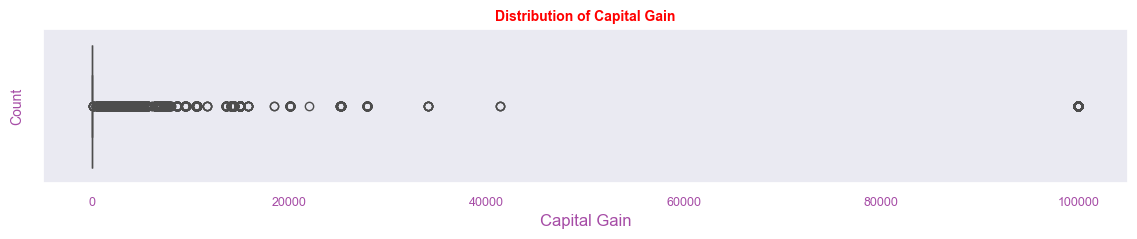

In [46]:
plt.figure(figsize=(14, 2))
sns.boxplot(x= data["capital-gain"], palette= "bright6")
plt.title("Distribution of Capital Gain", fontsize= 10, fontweight= "bold", color= "Red")
plt.xlabel("Capital Gain", color= "purple", fontsize= 12, alpha= 0.7)
plt.xticks(fontsize= 9, color= "purple", alpha= 0.7)
plt.ylabel("Count", color= "purple", fontsize= 10, alpha= 0.7)
plt.yticks(fontsize= 9, color= "purple", alpha= 0.7)
plt.show()

**`Highly skewed distribution`** - Most observations are clustered near zero with very few high-value outliers

**`Majority earn little to no capital gains`** - The dense cluster of dots at the left indicates most people (+90%) have capital gains close to $0

**`Few high earners`** - Only a small number of individuals have substantial capital gains above $20,000

**`Extreme outlier present`** - One data point appears around $100,000, showing significant wealth concentration

**`Typical wealth inequality pattern`** - This distribution reflects how capital gains are concentrated among a small percentage of the population

---
----
----
----
-----

### **2.  Distribution of Capital Loss:**

In [47]:
data.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'salary'],
      dtype='object')

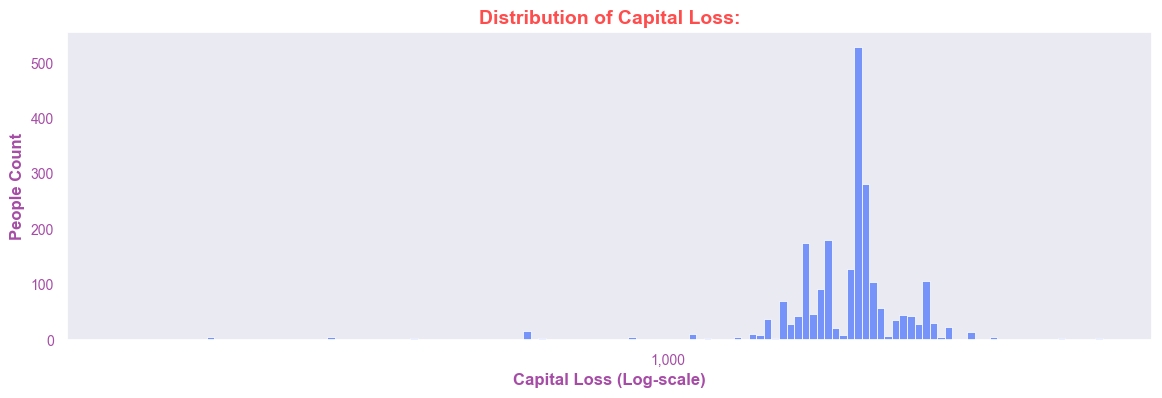

In [53]:
plt.figure(figsize=(14, 4))
sns.set_theme(context= "notebook", style= "dark", palette= "bright6", font_scale= 1.2)
sns.histplot(data["capital-loss"], kde=True, log_scale=True, legend= True, palette= "bright6")
plt.title("Distribution of Capital Loss:", fontsize= 14, fontweight= "bold", color= "Red", alpha= 0.7)
plt.xlabel("Capital Loss (Log-scale)", fontsize= 12, color= "purple", alpha= 0.7, fontweight= "bold")
plt.ylabel("People Count", fontsize= 12, color= "purple", alpha= 0.7, fontweight= "bold")
plt.xticks(fontsize= 10, color= "purple", alpha= 0.7)
plt.yticks(fontsize= 10, color= "purple", alpha= 0.7)
plt.gca().set_xticklabels([f"{int(x):,}" for x in plt.gca().get_xticks().tolist()])
plt.show()

**Heavily right-skewed distribution** - Most people have zero or very small capital losses, with frequency declining as losses increase

**Peak near zero** - The highest bar shows most individuals experience minimal capital losses

**Few large losses** - Small number of people experience substantial capital losses (right tail of distribution)

**Opposite of gains pattern** - While gains were concentrated among few, losses show most people have some small losses with fewer experiencing large losses

**Long right tail** - The distribution extends far to the right, indicating some individuals face very significant capital losses

Compared to the size of dataset, `capital-loss` values are very few in number and can be treated like categorical values.

In [49]:
data["capital-loss"].unique()

array([   0, 1721, 1876, 2415, 1887,  625, 1977, 2057, 1429, 1590, 1485,
       2051, 2377, 1672, 1628, 1902, 1602, 1741, 2444, 1408, 2001, 2042,
       1740, 1825, 1848, 1719, 3004, 2179, 1573, 2205, 1258, 2339, 1726,
       2258, 1340, 1504, 2559, 1668, 1974, 1980, 1564, 2547, 2002, 1669,
       1617,  323, 3175, 2472, 2174, 1579, 2129, 1510, 1735, 2282, 1870,
       1411, 1911, 1651, 1092, 1762, 2457, 2231, 2238,  653, 1138, 2246,
       2603, 2392, 1944, 1380, 2465, 1421, 3770, 1594,  213, 2149, 2824,
       1844, 2467, 2163, 1816, 1648, 2206, 2352,  419, 1539,  880,  810,
        974, 4356, 2489, 1755, 3683, 2267, 2080,  155, 3900, 2201, 2754])

In [56]:
sas= data.groupby("capital-loss")["capital-loss"].value_counts().reset_index()
sas

,capital-loss,count
0,0,40203
1,155,1
2,213,5
3,323,5
4,419,3
...,...,...
94,3175,2
95,3683,2
96,3770,4
97,3900,2


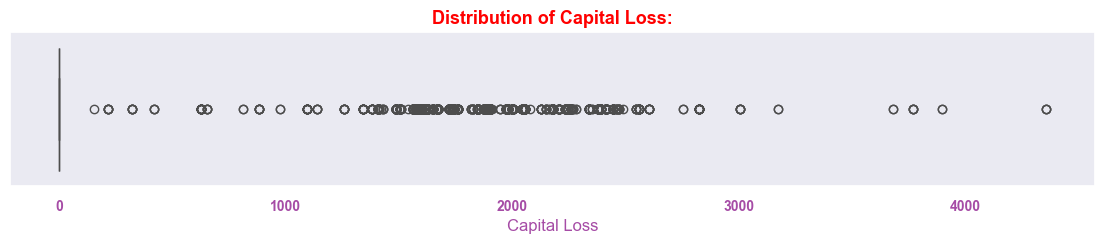

In [69]:
plt.figure(figsize=(14, 2))
sns.set_theme(context= "notebook", style= "dark", palette= "bright6", font_scale= 1.2)
sns.boxplot(data= data, x= "capital-loss", palette= "bright6")
plt.title("Distribution of Capital Loss:", fontsize= 13, fontweight= "bold", color= "Red")
plt.xlabel("Capital Loss", color= "purple", fontsize= 12, alpha= 0.7)
plt.xticks(color= "Purple", alpha= 0.7, fontsize= 10, fontweight= "bold")
plt.show()

---
---
----
-----
----

### **3. Capital Gain vs Salary:**

In [73]:
data.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'salary'],
      dtype='object')

In [74]:
data.head(3)

,age,workclass,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,salary
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K


In [76]:
data.groupby(by= "salary")["capital-gain"].mean().reset_index()

,salary,capital-gain
0,<=50K,170.175859
1,>50K,4462.668262


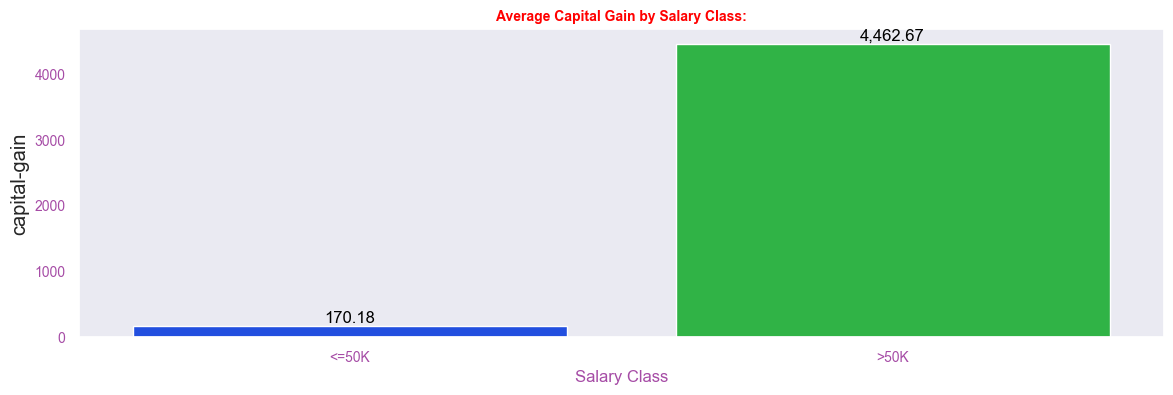

In [80]:
plt.figure(figsize=(14, 4))
sns.set_theme(context= "notebook", style= "dark", palette= "bright6", font_scale= 1.2)
sns.barplot(x= "salary", y= "capital-gain", data= data.groupby(by= "salary")["capital-gain"].mean().reset_index(), palette= "bright6")
# add annotations
for i, v in enumerate(data.groupby(by= "salary")["capital-gain"].mean().reset_index()["capital-gain"]):
    plt.text(i, v + 0.01, str(f'{round(v, 2):,}'), ha= "center", va= "bottom", fontsize= 12, color= "black")    
plt.title("Average Capital Gain by Salary Class:", fontsize= 10, fontweight= "bold", color= "Red")
plt.xlabel("Salary Class", color= "purple", fontsize= 12, alpha= 0.7)
plt.xticks(fontsize= 10, color= "purple", alpha= 0.7)
plt.yticks(fontsize= 10, color= "purple", alpha= 0.7)
plt.show()

**Dramatic income disparity** - High earners (>$50K) have 26x higher average capital gains than lower earners (≤$50K)

**Low earners have minimal gains** - Those earning ≤$50K average only $170.18 in capital gains

**High earners dominate capital gains** - Those earning >$50K average $4,462.67 in capital gains

**Wealth begets wealth** - Higher salary earners also generate significantly more investment income

**Investment access correlation** - The gap suggests higher-income individuals have better access to investment opportunities or more capital to invest

This shows the capital gains primarily benefit higher-income groups, contributing to wealth inequality.

In [120]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

Text(0.5, 1.0, 'Capital Gain & Salary Class:')

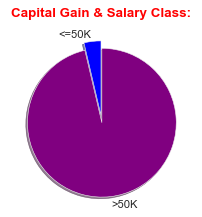

In [136]:
plt.figure(figsize=(3, 3))
# Set theme for matplotlib plot
plt.style.use("seaborn-v0_8-dark-palette")
plt.pie(data.groupby(by= "salary")["capital-gain"].mean().reset_index()["capital-gain"], labels= data.groupby(by= "salary")["capital-gain"].mean().reset_index()["salary"], shadow= True, startangle= 90, colors=["blue", "purple"], explode= [0, 0.1])
plt.title("Capital Gain & Salary Class:", fontsize= 12, fontweight= "bold", color= "Red")

- The vast majority (purple section) of total capital gains go to people earning >$50K

- Those earning ≤$50K (small blue slice) receive only a tiny fraction of total capital gains

- Despite potentially being a smaller population, high earners capture most capital gains income

- Shows how capital gains as a form of wealth are heavily skewed toward higher-income individuals

- Confirms the pattern from the bar chart showing capital gains primarily benefit the higher salary class

---
---
-----
----
---

### **4. Capital Gain vs Age:**

Objective: See if older people report more capital gains.
How: Scatter plot with age and capital-gain.

In [137]:
data.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'salary'],
      dtype='object')

In [138]:
data.head(3)

,age,workclass,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,salary
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K


<Axes: xlabel='age', ylabel='capital-gain'>

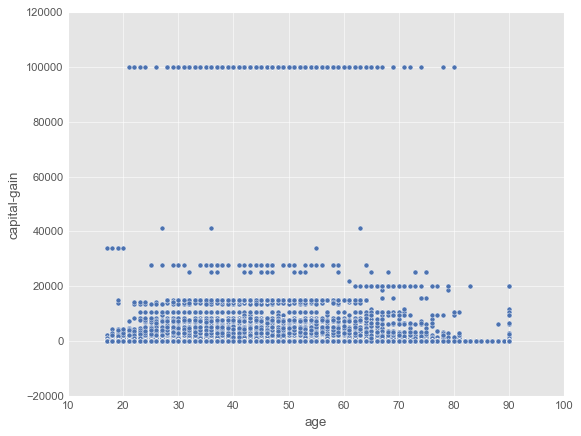

In [139]:
sns.scatterplot(x= "age", y= "capital-gain", data= data, palette= "bright6")

In [ ]:
data[["age", "capital-gain"]].corr(method= "spearman") # Checking for monotonic relationship

,age,capital-gain
age,1.000000,0.114719
capital-gain,0.114719,1.000000


**`Weak positive correlation`** - The correlation coefficient of `0.114719` indicates a slight positive relationship between age and capital gains. 

**`Low predictive power`** - With `r = 0.11`, age explains only about 1.3% of the variance in capital gains (`r² ≈ 0.013`)

**`Statistically weak relationship`** - While positive, the correlation is close to zero, suggesting age single is not a strong predictor of capital gains

**`Older individuals trend slightly higher`** - There's a modest tendency for older people to have higher capital gains, but with many exceptions

**`Other factors more important`** - The low correlation suggests variables like income, education, or investment knowledge likely have much stronger relationships with capital gains. Age alone is not a reliable indicator for predicting someone's capital gains income.